# 04 — Fairness / Sub-group Performance Audit

Checks whether the fraud model treats protected groups equitably. The public benchmark has no
demographics, so we attach **synthetic proxy attributes** (age band, region) and compare
decline/flag rate, false-positive rate, and recall across groups. Headline = the **disparity
ratio** (worst/best) per metric: ~1.0 is equitable, > 1.2 warrants review.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

from fraud.train.dataset import load_raw, time_split
from fraud.models.stacking import StackingFraudModel
from fraud.fairness.subgroup import add_synthetic_attributes, subgroup_report, disparity

splits = time_split(load_raw(50_000))
model = StackingFraudModel().fit(splits.X_train, splits.y_train, splits.X_holdout, splits.y_holdout)
scores = model.predict_proba(splits.X_test)
decisions = model.policy.decide(scores)
print("scored test set:", len(scores))

[info] IEEE-CIS not downloaded; using synthetic data. See data/README.md.


scored test set: 10000


## 1. Attach synthetic protected attributes

In [2]:
attrs = add_synthetic_attributes(len(splits.X_test), seed=7)
attrs.index = splits.X_test.index
attrs.head()

,age_band,region
40000,41-60,Wellington
40001,60+,Waikato
40002,41-60,Otago
40003,26-40,Wellington
40004,26-40,Auckland


## 2. Sub-group performance report

In [3]:
report = subgroup_report(splits.y_test, scores, decisions, attrs, max_fpr=0.02)
display(report.style.format({"fraud_rate":"{:.3f}","flag_rate":"{:.3f}",
                             "fpr":"{:.3f}","recall_at_fpr":"{:.3f}"}))

## 3. Disparity ratios

In [4]:
for metric in ["flag_rate", "fpr", "recall_at_fpr"]:
    d = disparity(report, metric)
    print(f"--- {metric} ---")
    print(d.to_string())
    print()

--- flag_rate ---
              metric  disparity_ratio worst_group  best_group
attribute                                                    
age_band   flag_rate         1.025669       41-60       18-25
region     flag_rate         1.033458       Otago  Wellington

--- fpr ---
          metric  disparity_ratio worst_group  best_group
attribute                                                
age_band     fpr         1.024259       41-60       18-25
region       fpr         1.040674       Otago  Wellington

--- recall_at_fpr ---
                  metric  disparity_ratio worst_group best_group
attribute                                                       
age_band   recall_at_fpr         1.402576         60+      18-25
region     recall_at_fpr         1.544962  Wellington    Waikato



## 4. Visual comparison

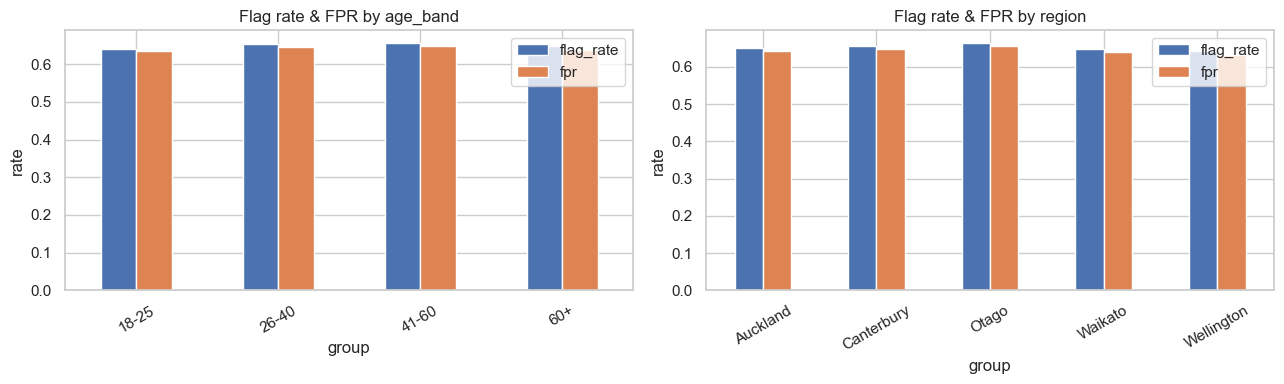

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for i, attr in enumerate(["age_band", "region"]):
    sub = report.loc[attr]
    sub[["flag_rate", "fpr"]].plot(kind="bar", ax=ax[i])
    ax[i].set_title(f"Flag rate & FPR by {attr}"); ax[i].set_ylabel("rate")
    ax[i].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Takeaway:** because the synthetic attributes are independent of fraud, disparity ratios
sit near 1.0 — the model is not keying on these proxies. On real data this same audit is how
you'd detect (and then mitigate, e.g. via group-aware thresholds) any systematic bias before
deployment. The report and ratios go straight into the **model card**.